# Reviewer walkthrough — *Ad Uplift & Observational Bias Analysis*

**Purpose of this notebook:** let a reviewer verify every number behind the resume points in ~2 minutes.
It only *loads committed result files* (`results/`) — no downloads, no API keys, no model training.
Full reproduction paths are in `REPRODUCING.md`; every claim's provenance is a row in `CLAIMS.md`.

**The project in one paragraph:** the Criteo uplift dataset is a real randomized experiment
(13.98M users; ad exposure randomized; visits/conversions tracked). Randomization gives us the *true*
causal effect, so we can (1) synthetically corrupt the data into "observational" versions and measure
exactly how wrong non-experimental methods are (H3), (2) estimate *who* responds via CATE learners with
formal heterogeneity inference (H1), and (3) test whether uplift-based ad targeting beats standard
propensity targeting under a budget (H2). All hypotheses were pre-registered (`HYPOTHESES.md`) with
Holm-corrected inference.

In [1]:
# Final Holm-corrected family verdicts (computed in Stage 5 from the pre-registered family)
import json, pandas as pd
finals = json.load(open("../results/stage5/finals.json"))
pd.DataFrame(finals["holm"]["family"]).T.join(
    pd.Series(finals["holm"]["verdicts"], name="verdict"))

,p,threshold,significant_after_holm,verdict
H3,0.0,0.016667,True,supported
H1,0.0,0.025,True,supported
H2,0.999,0.05,False,rejected (effect opposite registered direction)


## H3 — "How wrong without the experiment?" (the headline)

We corrupt the RCT with a *pre-registered* confounding mechanism at increasing severity, then re-estimate
the treatment effect naively and with corrections. Because the RCT's true effect is known, the bias of
each estimator is exact, not conjectured. At the pre-registered severity (γ\*=1.0): **naive estimation
overshoots 5.9×; cross-fitted AIPW (doubly-robust) recovers 93.7% of the gap** — and the same machinery
provably fails when the confounder is unobserved (the honest boundary of the method).

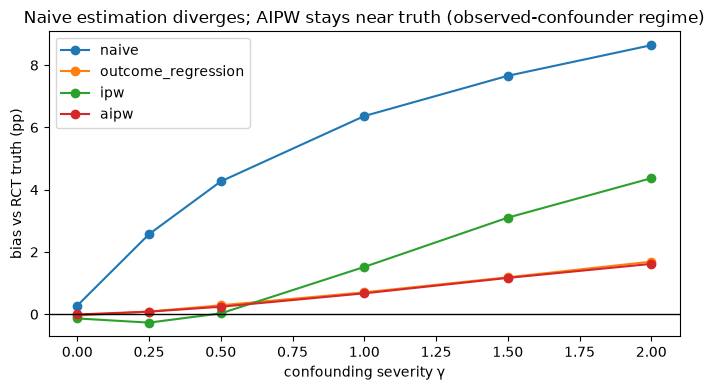

In [2]:
# Bias vs severity, averaged over replicates: naive vs corrections (visit outcome, primary mechanism)
import matplotlib.pyplot as plt
bg = pd.read_csv("../results/stage3/bias_grid.csv")
prim = bg[(bg.arm == "primary") & (bg.outcome == "visit")]
truth = finals["aipw_companion_full"]["visit"]["aipw"]  # full-RCT AIPW = ground-truth anchor
g = prim.groupby("severity")[["naive", "outcome_regression", "ipw", "aipw"]].mean()
ax = (g - truth).mul(100).plot(marker="o", figsize=(7, 4))
ax.axhline(0, color="k", lw=1); ax.set_ylabel("bias vs RCT truth (pp)"); ax.set_xlabel("confounding severity γ")
ax.set_title("Naive estimation diverges; AIPW stays near truth (observed-confounder regime)")
plt.tight_layout()

## H1 — Is there real treatment-effect heterogeneity?

Chernozhukov et al. BLP test on a held-out DR-learner proxy: β₂ > 0 means predicted CATE differences
correspond to *real* effect differences. β₂ = 0.384 (se 0.039), p = 9.9e-23 — survives Holm.

In [3]:
blp = json.load(open("../results/stage2/h1_blp.json"))["primary"]["blp"]
pd.Series(blp).to_frame("H1 primary (visit, DR proxy)")

,"H1 primary (visit, DR proxy)"
beta1_ate,9.555642e-03
beta1_se,5.463119e-04
beta2_het,3.836735e-01
beta2_se,3.909682e-02
beta2_p_value,9.857075e-23
n,1.000000e+06
p_assign,8.500000e-01


## CATE learner comparison (Qini/AUUC, seeded bootstrap CIs)

Causal forest leads on both outcomes. (A published campus project on this dataset reported AUUC 0.64
with an S-Learner — normalization conventions may differ, so treat as directional context.)

In [4]:
m = json.load(open("../results/stage2/metrics.json"))
rows = [{"outcome": o, "learner": l, "AUUC_norm": round(v["auuc_normalized"], 3),
         "qini": round(v["qini"]["point"], 5),
         "qini_CI": f"[{v['qini']['ci_lo']:.5f}, {v['qini']['ci_hi']:.5f}]"}
        for o in ("visit", "conversion") for l, v in m[o].items() if isinstance(v, dict)]
pd.DataFrame(rows)

,outcome,learner,AUUC_norm,qini,qini_CI
0,visit,t_learner,0.711,0.00187,"[0.00146, 0.00223]"
1,visit,x_learner,0.730,0.00204,"[0.00163, 0.00243]"
2,visit,dr_learner,0.732,0.00206,"[0.00165, 0.00246]"
3,visit,causal_forest,0.836,0.00298,"[0.00261, 0.00337]"
4,conversion,t_learner,0.710,0.00021,"[0.00011, 0.00032]"
5,conversion,x_learner,0.779,0.00028,"[0.00018, 0.00038]"
6,conversion,dr_learner,0.582,0.00008,"[-0.00002, 0.00018]"
7,conversion,causal_forest,0.810,0.00033,"[0.00022, 0.00044]"


## H2 — The pre-registered negative (kept, not buried)

Budget-constrained targeting: rank customers by predicted CATE, treat the top k%. On the pre-registered
test, **uplift targeting *underperformed* plain propensity targeting** on incremental conversions
(Δ = −253 at k=10%, −329 at k=30%, p=0.002 in the *opposite* direction). Interpretation: at a 0.3%
conversion base rate there are effectively no "sure things" to skip — the classic uplift argument
loses its bite. Reported as a rejected hypothesis per protocol.

In [5]:
pol = json.load(open("../results/stage4/policy_results.json"))
pd.DataFrame(pol["h2"]["primary"]).T

,k,delta,ci_lo,ci_hi,p_boot,B,seed
k10,0.1,-253.321999,-374.302756,-120.951633,0.002,500.0,20260717.0
k30,0.3,-329.176716,-444.074254,-199.913949,0.002,500.0,20260717.0


## Resume-point → evidence map

| Resume point | Verified by |
| --- | --- |
| RCT as causal ground truth (13.98M users) | `results/stage1/`, notebook 01, gate_stage1 |
| Naive bias 5.9×; AIPW recovers 93.7% [92.1, 95.3] | CLAIMS C12–C15, notebook 04, cell above |
| Heterogeneity: BLP β₂=0.38, Holm-corrected; causal forest best AUUC | CLAIMS C8–C11, notebook 02, cells above |
| Pre-registered negative: uplift targeting lost to propensity targeting | CLAIMS C17–C18, notebook 03, cell above |

**Full verification:** `uv sync --frozen && uv run pytest -q` (52 tests) or the tiered paths in `REPRODUCING.md`.
Fresh-machine log: `results/fresh_machine_run.log` (Tier 1 in 2m19s).